The following Jupyter notebook walks the user through the analysis of their MC-ICP-MS data obtained from the Indiana University Heavy Metal Isotope Lab. Examples are provided of the use of functions from various custom libraries created by Barrett Gibbs in Python. Make sure that any files you are wanting to analyze are in the same repository as this Jupyter notebook and its associated libraries. Necessary libraries can be seen in the import cel below. Make sure all libraries can be imported!

In [1]:
#Import cel

#external libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as pxl


#custom libraries
import tl_data_organization as org
import geochem_eqns as ge
import tl_plot_aid as tlplt

MAJOR ACADEMIC INTEGRITY NOTE FOR EAS G690!!!!!

To test my code on more data than I currently have access to, I created a file of fabricated data built upon the real data file I was previously given. The file "first_tl_file.xlsx" is a real Tl isotope MC-ICP-MS data file, and the expanded data of "fabricated_data" is fabricated. Furthermore, many mineral names I have used in this file most likely are not accurate. Although amazonite (feldspar), mica, and Mn Nodules were being used in the real data file, I am unsure which sample codenames correspond to which mineral. This is all test data built around a file of the format that I will generate when I conduct my experiments in the MC-ICP-MS experiments this spring. This file will not be shared with other students until it has used with real data that I have produced and thoroughly critiqued by experts.While my markdown cells are written for users, I do not anticipate users of this file soon.

Add the file name(s) of all of your Tl MC-ICP-MS data files to the following list as strings like this: 

MC_ICP_MW_Files = ['file_1.xlsx','file_2.xlsx',...]


In [2]:
#Reads in files and constructs a dataframe

MC_ICP_MS_Files = ['first_tl_file.xlsx']

data_frames = []
#creates list with dataframes
for i in range(len(MC_ICP_MS_Files)):
    data_frames.append(pd.read_excel(MC_ICP_MS_Files[i]))


Samples are "bracketed" by standards. By bracketing the samples with standards, instrument drift is prevented by MC-ICP-MS software correction. Of course, this means that the first and last entries in each column are standards, and every other entry is sample. Therefore, the custom function below extracts lists of standards and lists of samples by going through specific data frame columns in "steps" of two.

In [3]:
org.names_and_raw_values(data_frames)

[[[2.388544, 'DU-10 (BCR-2)'],
  [2.388954, 'DS-13'],
  [2.389119, 'DS-13'],
  [2.389196, 'DS-13'],
  [2.388385, 'DS-14'],
  [2.388145, 'DS-14'],
  [2.388075, 'DS-14'],
  [2.391621, 'NOD-A-1']],
 [[0.00014, 'DU-10 (BCR-2)'],
  [5.43e-05, 'DS-13'],
  [7.7e-05, 'DS-13'],
  [6.97e-05, 'DS-13'],
  [0.000141, 'DS-14'],
  [0.00012, 'DS-14'],
  [0.000161, 'DS-14'],
  [5.06e-05, 'NOD-A-1']]]

The raw MC-ICP-MS code file that you are analyzing most likely has "code names" for samples. Seeing as this program is developed to track isotopic data in plant parts grown in varying mineral substrates, the following custom function has been created for you to assign mineral names and plant parts to whatever sample name/ID currently exists in your raw MC-ICP-MS data file. To use this function, input as a list of strings the EXACT name/ID listed in your raw file, a corresponding list of desired names, and a list of the location of the data as integers where [0, 1, 2, 3, 4, 5] = [Substrate, Stem, Leaves, Flower Stems, Flowers, Seed Pods].

Example: Your data file has three measurements: Nod-2, Nod-27, Am-8. These correspond to samples derived from Mn nodules at stem, Mn nodules at flowers, and substrate amazonite. The function might look as follows:

org.redefine_names(['Nod-2', 'Nod-27', 'Am-8'], ['Mn Nodule', 'Mn Nodule', 'Amazonite'], [1, 4, 0])


In [4]:
org.redefine_names(['Nod-2', 'Nod-27', 'Am-8'], ['Mn Nodule', 'Mn Nodule', 'Amazonite'], [1, 4, 0])

[['Nod-2', 'Mn Nodule', 'stem'],
 ['Nod-27', 'Mn Nodule', 'flowers'],
 ['Am-8', 'Amazonite', 'substrate']]

The custom function org.names_and_raw_values (as seen above) is structured around whatever names/IDs are in your raw excel file. The following cell has been created such that your prefered data names will be inserted into the lists created by names_and_raw_values. This function org.solidify_name_schematic() uses both the org.redefine_names() function and the org.names_and_raw_values() function. Therefore, its input paramaters are the input parameters of those two functions. An example of how to use this function is in the cell below. Please assign your call of this function to the variable our_working_data as shown in the example. Our_Working_Data will be the main datastructure manipulated/used throughout the file.

In [5]:
our_working_data = org.solidify_name_schematic(data_frames, ['DU-10 (BCR-2)','DS-13','DS-14','NOD-A-1'], ['mica','Amazonite','mica','Mn Nodule'], [4,2,1,0])
our_working_data

[[[2.388544, 'mica', 'flowers'],
  [2.388954, 'Amazonite', 'leaves'],
  [2.389119, 'Amazonite', 'leaves'],
  [2.389196, 'Amazonite', 'leaves'],
  [2.388385, 'mica', 'stem'],
  [2.388145, 'mica', 'stem'],
  [2.388075, 'mica', 'stem'],
  [2.391621, 'Mn Nodule', 'substrate']],
 [[0.00014, 'mica', 'flowers'],
  [5.43e-05, 'Amazonite', 'leaves'],
  [7.7e-05, 'Amazonite', 'leaves'],
  [6.97e-05, 'Amazonite', 'leaves'],
  [0.000141, 'mica', 'stem'],
  [0.00012, 'mica', 'stem'],
  [0.000161, 'mica', 'stem'],
  [5.06e-05, 'Mn Nodule', 'substrate']]]

One thing you might be noticing is that all of these isotope ratio values are very similar to each other. Seeing as you are a geochemist (or perhaps a geochemist in training), you probably recognize that we should convert these values to the epsilon or delta notation. Custom functions have been created to do just that in the geochem_eqns.py library. For the rest of this notebook, we will be working in epsilon notation as it is what is most common in Tl studies. However, the geochem_eqns library can also convert values to delta notation.

In [6]:
epsilon_data = ge.epsilon_vals(our_working_data)
epsilon_data

[[5.881515118508762, 'mica'],
 [7.599051584741279, 'Amazonite'],
 [8.290255284566506, 'Amazonite'],
 [8.61281701115102, 'Amazonite'],
 [5.215446098678633, 'mica'],
 [4.2100588989346655, 'mica'],
 [3.9168209656748054, 'mica'],
 [18.771416841911748, 'Mn Nodule']]

Run the following cell to change your working data variable from raw isotope ratios to epsilon notation. Don't run the following if you wish to keep data raw.

In [7]:
for i in range(len(our_working_data[0])): #loops through 0 element of our_working_data
    our_working_data[0][i][0] = epsilon_data[i][0] #reassigns isotope ratios to epsilon notation
our_working_data

[[[5.881515118508762, 'mica', 'flowers'],
  [7.599051584741279, 'Amazonite', 'leaves'],
  [8.290255284566506, 'Amazonite', 'leaves'],
  [8.61281701115102, 'Amazonite', 'leaves'],
  [5.215446098678633, 'mica', 'stem'],
  [4.2100588989346655, 'mica', 'stem'],
  [3.9168209656748054, 'mica', 'stem'],
  [18.771416841911748, 'Mn Nodule', 'substrate']],
 [[0.00014, 'mica', 'flowers'],
  [5.43e-05, 'Amazonite', 'leaves'],
  [7.7e-05, 'Amazonite', 'leaves'],
  [6.97e-05, 'Amazonite', 'leaves'],
  [0.000141, 'mica', 'stem'],
  [0.00012, 'mica', 'stem'],
  [0.000161, 'mica', 'stem'],
  [5.06e-05, 'Mn Nodule', 'substrate']]]

The following cell's function will sort data by mineral groups for plotting. The first parameter is our_working_data. For the second parameter, use 0 for isotope data and 1 for isotope error data.

In [8]:
dat = tlplt.sort_the_min_groups(our_working_data,1)
dat #displays list of error values, list of mineral names, and list of sample parts/locations all within one list

[[0.00014, 5.43e-05, 7.7e-05, 6.97e-05, 0.000141, 0.00012, 0.000161, 5.06e-05],
 ['mica',
  'Amazonite',
  'Amazonite',
  'Amazonite',
  'mica',
  'mica',
  'mica',
  'Mn Nodule'],
 ['flowers',
  'leaves',
  'leaves',
  'leaves',
  'stem',
  'stem',
  'stem',
  'substrate']]

The following cell's function organizes data such that it can be plotted with an x axis being the data and the y axis being the plant experiment part (substrate, leaves,...). This function works for ONE SINGULAR MINERAL. The parameters are your data, the mineral you want to plot as you named it via the tl_data_organization library, and an int value 0 or 1. 0 plots isotopic data values (normalized isotope 205/203 values from the excel file(s)), and 1 plots their errors.

In [9]:
tlplt.data_plotter_for_one_min(our_working_data,'Amazonite',0)

[[nan,
  nan,
  nan,
  7.599051584741279,
  8.290255284566506,
  8.61281701115102,
  nan,
  nan,
  nan],
 ['substrate',
  'stem',
  'leaves',
  'leaves',
  'leaves',
  'leaves',
  'flower stems',
  'flowers',
  'seed pods']]

The following cell constructs a scatter plot of epsilon values using the tl_plot_aid custom library and the matplotlib.pyplot external library. Plots are produced using this method throughout the notebook! If you are using this notebook for your own data analysis, makes sure to make the first parameter in plt.scatter() what you want to plot on the x-axis, and make the second parameter your y part values. 

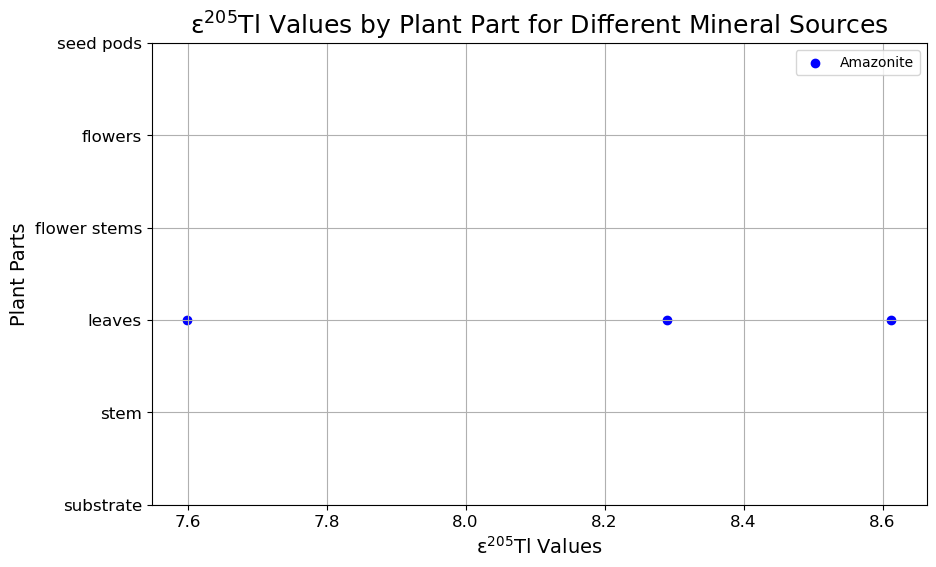

In [10]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(tlplt.data_plotter_for_one_min(our_working_data,'Amazonite',0)[0], \
    tlplt.data_plotter_for_one_min(our_working_data,'Amazonite',0)[1], color='blue', label='Amazonite')   
plt.xlabel('ε$^{205}$Tl Values',fontsize=14)
plt.ylabel('Plant Parts',fontsize=14)
#y_all and yticks suggested by chatgpt
y_all = ['substrate', 'stem','leaves','flower stems','flowers','seed pods']
plt.yticks(y_all)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('ε$^{205}$Tl Values by Plant Part for Different Mineral Sources', fontsize=18)
plt.legend()
plt.grid(True)
plt.show()

The following cell constructs a plot just like the last cell, but the mica and Mn Nodule data are added. 

This is one of my two "publication quality" figures. There are no units on the epsilon values because they are values constructed from ratios. This figure is similar to figures you'd see in journals such as the American Chemical Society published Environmental Science and Technology.

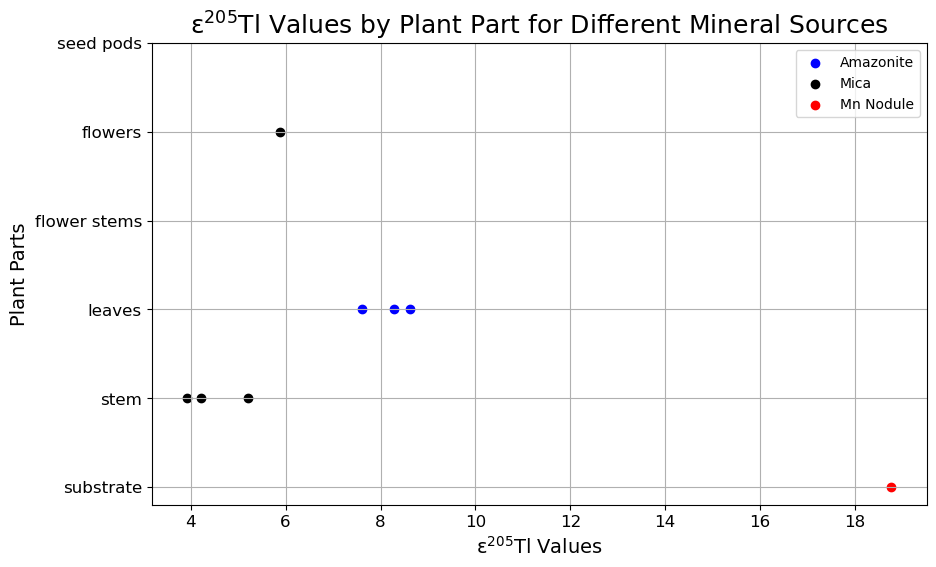

In [11]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(tlplt.data_plotter_for_one_min(our_working_data,'Amazonite',0)[0], \
    tlplt.data_plotter_for_one_min(our_working_data,'Amazonite',0)[1], color='blue', label='Amazonite')  
plt.scatter(tlplt.data_plotter_for_one_min(our_working_data,'mica',0)[0], \
    tlplt.data_plotter_for_one_min(our_working_data,'mica',0)[1], color='black', label='Mica')
plt.scatter(tlplt.data_plotter_for_one_min(our_working_data,'Mn Nodule',0)[0], \
    tlplt.data_plotter_for_one_min(our_working_data,'Mn Nodule',0)[1], color='red', label='Mn Nodule')
plt.xlabel('ε$^{205}$Tl Values',fontsize=14)
plt.ylabel('Plant Parts',fontsize=14)
#y_all and yticks suggested by chatgpt
y_all = ['substrate', 'stem','leaves','flower stems','flowers','seed pods']
plt.yticks(y_all)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('ε$^{205}$Tl Values by Plant Part for Different Mineral Sources', fontsize=18)
plt.legend()
plt.grid(True)
plt.show()

The custom function tlplt.calc_min_averages will calculate average isotopic values or error values from ONE specific mineral. Similarly to previous functions, the input is your working dataset (our_working_data), the mineral name, and an integer value 0 or 1 to indicate if you are calculating based on isotopic values or error values. 0 is for the 205/203 isotope values, and 1 is for the error values.

In [12]:
tlplt.calc_min_averages(our_working_data,'Amazonite',0)

[[nan, nan, np.float64(8.167374626819601), nan, nan, nan],
 ['substrate', 'stem', 'leaves', 'flower stems', 'flowers', 'seed pods']]

The following is a plot of the average values computed in the last cell. Nothing is structurally different about this plot compared to the plot of Amazonite show earlier accept for the modification of two lines to plot averages instead of all values. Said two lines are commented on with a #comment. 

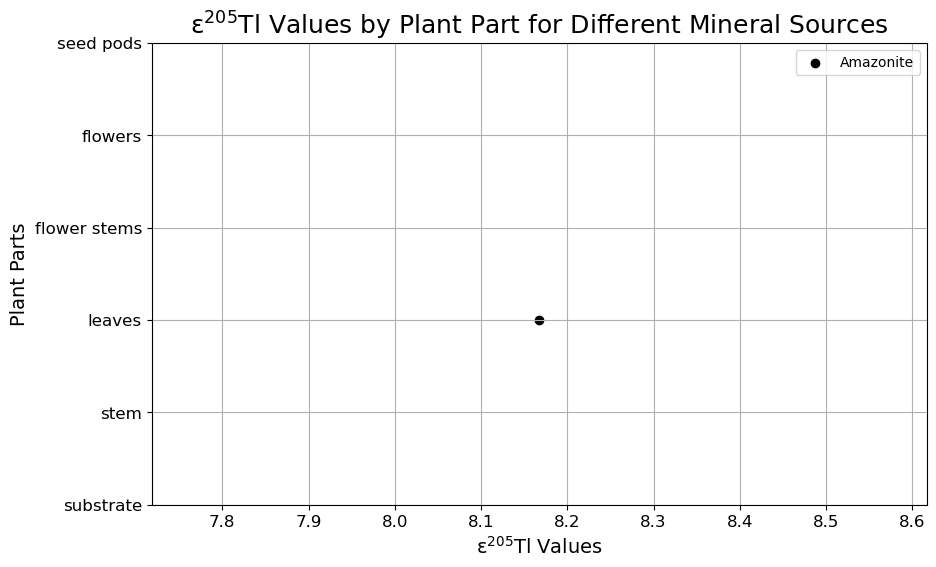

In [13]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(tlplt.calc_min_averages(our_working_data,'Amazonite',0)[0], #calcs and plots averages
    tlplt.calc_min_averages(our_working_data,'Amazonite',0)[1], color='black', label='Amazonite') #plots parts for averages 
plt.xlabel('ε$^{205}$Tl Values',fontsize=14)
plt.ylabel('Plant Parts',fontsize=14)
#y_all and yticks suggested by chatgpt
y_all = ['substrate', 'stem','leaves','flower stems','flowers','seed pods']
plt.yticks(y_all)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('ε$^{205}$Tl Values by Plant Part for Different Mineral Sources', fontsize=18)
plt.legend()
plt.grid(True)
plt.show()

I am now going to be using the fabricated data

In [14]:
#Reads in files and constructs a dataframe

MC_ICP_MS_Files = ['fabricated_data.xlsx'] #This fabricated dataset is of "one" mineral

data_frames = []
#creates list with dataframes
for i in range(len(MC_ICP_MS_Files)):
    data_frames.append(pd.read_excel(MC_ICP_MS_Files[i]))

In [15]:
#creates working data structure
our_working_data = org.solidify_name_schematic(data_frames, ['Feldsp0','Feldsp1','Feldsp2','Feldsp3','Feldsp4','Feldsp5'], ['Feldspar','Feldspar','Feldspar','Feldspar','Feldspar','Feldspar'], [0,1,2,3,4,5])
our_working_data

[[[2.388544, 'Feldspar', 'stem'],
  [2.388954, 'Feldspar', 'substrate'],
  [2.389119, 'Feldspar', 'flower stems'],
  [2.389196, 'Feldspar', 'seed pods'],
  [2.388385, 'Feldspar', 'leaves'],
  [2.388145, 'Feldspar', 'leaves'],
  [2.388075, 'Feldspar', 'flowers'],
  [2.391621, 'Feldspar', 'substrate'],
  [2.38803390542606, 'Feldspar', 'flower stems'],
  [2.3886655205103, 'Feldspar', 'flowers'],
  [2.38888982842482, 'Feldspar', 'leaves'],
  [2.3903029933468, 'Feldspar', 'substrate'],
  [2.38910995161645, 'Feldspar', 'stem'],
  [2.38842099355866, 'Feldspar', 'flowers'],
  [2.38870307477637, 'Feldspar', 'seed pods'],
  [2.39015394837264, 'Feldspar', 'leaves'],
  [2.38921960057353, 'Feldspar', 'substrate'],
  [2.38925428081249, 'Feldspar', 'substrate'],
  [2.38834231281117, 'Feldspar', 'seed pods'],
  [2.38841502787307, 'Feldspar', 'substrate'],
  [2.38923394430462, 'Feldspar', 'seed pods'],
  [2.3899912356116, 'Feldspar', 'substrate'],
  [2.3901445725232, 'Feldspar', 'flower stems'],
  [2.3

The following cell generates a plot of the shifts in isotope values of a feldspar with a line connecting the datapoints for better visualization. This type of graph is very similar those seen in journals such as Environmental Science and Technology. The x-axis doesn't have a unit because it is a value from the comparison of ratios. This is another publication quality plot. 

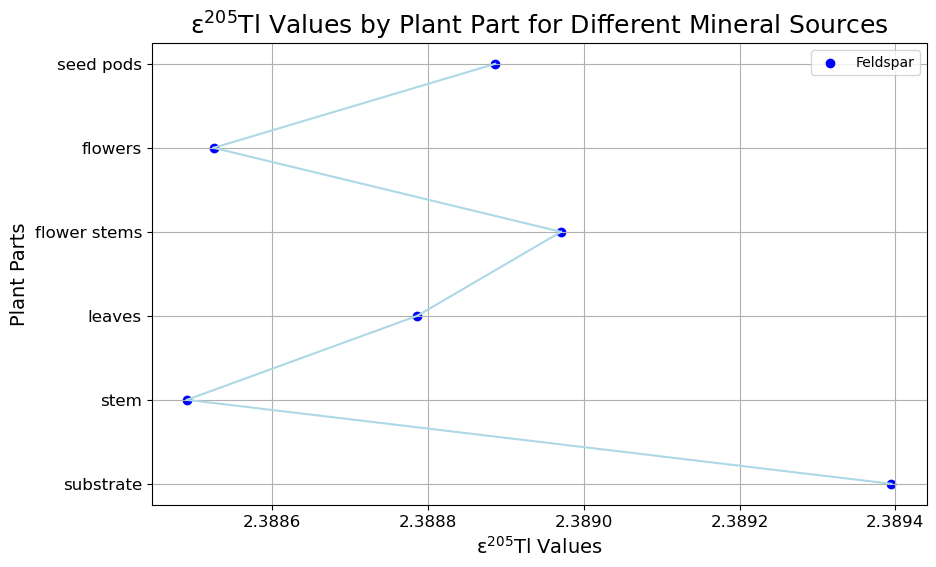

In [16]:
#plots averages for the mineral in the much larger fabricated data seet
plt.figure(figsize=(10, 6))
plt.scatter(tlplt.calc_min_averages(our_working_data,'Feldspar',0)[0], #calcs and plots averages
    tlplt.calc_min_averages(our_working_data,'Feldspar',0)[1], color='blue', label='Feldspar') #plots parts for averages 
plt.xlabel('ε$^{205}$Tl Values',fontsize=14)
plt.ylabel('Plant Parts',fontsize=14)
#y_all and yticks suggested by chatgpt
y_all = ['substrate', 'stem','leaves','flower stems','flowers','seed pods']
plt.yticks(y_all)

rangeVal = len(tlplt.calc_min_averages(our_working_data,'Feldspar',0)[0])

#connect data points with lines ---- this was written with Github Copilot but modified to be lightblue
for i in range(rangeVal-1):
    plt.plot(tlplt.calc_min_averages(our_working_data,'Feldspar',0)[0][i:i+2], \
        tlplt.calc_min_averages(our_working_data,'Feldspar',0)[1][i:i+2], color='lightblue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('ε$^{205}$Tl Values by Plant Part for Different Mineral Sources', fontsize=18)
plt.legend()
plt.grid(True)
plt.show()

Parallelization

Note for Travis: I have realized that my original idea for parallelization was pretty ambitious, and I overestimated how long it would take to produce on my own and I under budgeted my time. For that reason, what I have here is very different than what I described on my outline, and I apologize. 

I have written a script simultaneous_plots.py that can generate many different plots at once. While this type of script might not be very applicable for a single lab, it could be good for generating many different figures of any isotope values in plants to store in databases from different universities and labs. 